In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [36]:
solar_data = pd.read_csv('SOLAR_PLANT_DATA(GENERATION_AND_WEATHER).csv')
solar_data["DATE_TIME"] = pd.to_datetime(solar_data["DATE_TIME"])

solar_data.iloc[10:30]

,DATE_TIME,PLANT_ID,IRRADIATION(W/m²),WIND_SPEED(m/s),CLOUD_COVER(%),AMBIENT_TEMPERATURE(°C),THEORETICAL_MODULE_TEMPERATURE(°C),ACTUAL_MODULE_TEMPERATURE(°C),THEORETICAL_DC_POWER(kW),THEORETICAL_AC_POWER(kW),...,AC_EFFICIENCY,INVERTER_EFFICIENCY,DAILY_YIELD(kWh),TOTAL_YIELD(kWh),THEORETICAL_DC_PER_KWP,THEORETICAL_AC_PER_KWP,CALCULATED_PLANT_CAPACITY(kWp),DC_RESIDUAL(kW),AC_RESIDUAL(kW),EFFICIENCY_RATIO
10,2020-05-15 02:30:00,4136001,0.000000,1.625000,97.50,26.260399,26.260399,24.482407,0.000000,NaN,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,25051.255361,0.000000,NaN,NaN
11,2020-05-15 02:45:00,4136001,0.000000,1.520833,97.25,26.297826,26.297826,24.488698,0.000000,NaN,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,25051.255361,0.000000,NaN,NaN
12,2020-05-15 03:00:00,4136001,0.000000,1.416667,97.00,26.328249,26.328249,24.506290,0.000000,NaN,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,25051.255361,0.000000,NaN,NaN
13,2020-05-15 03:15:00,4136001,0.000000,1.416667,97.50,26.158710,26.158710,24.595197,0.000000,NaN,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,25051.255361,0.000000,NaN,NaN
14,2020-05-15 03:30:00,4136001,0.000000,1.416667,98.00,26.078499,26.078499,24.801314,0.000000,NaN,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,25051.255361,0.000000,NaN,NaN
15,2020-05-15 03:45:00,4136001,0.000000,1.416667,98.50,26.001304,26.001304,24.607817,0.000000,NaN,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,25051.255361,0.000000,NaN,NaN
16,2020-05-15 04:00:00,4136001,0.000000,1.416667,99.00,25.697211,25.697211,24.626179,0.000000,NaN,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,25051.255361,0.000000,NaN,NaN
17,2020-05-15 04:15:00,4136001,0.000000,1.361111,99.00,25.627702,25.627702,24.773145,0.000000,NaN,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,25051.255361,0.000000,NaN,NaN
18,2020-05-15 04:30:00,4136001,0.000000,1.305556,99.00,25.482046,25.482046,24.796691,0.000000,NaN,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,25051.255361,0.000000,NaN,NaN
19,2020-05-15 04:45:00,4136001,0.000000,1.250000,99.00,25.230932,25.230932,24.436904,0.000000,NaN,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,25051.255361,0.000000,NaN,NaN


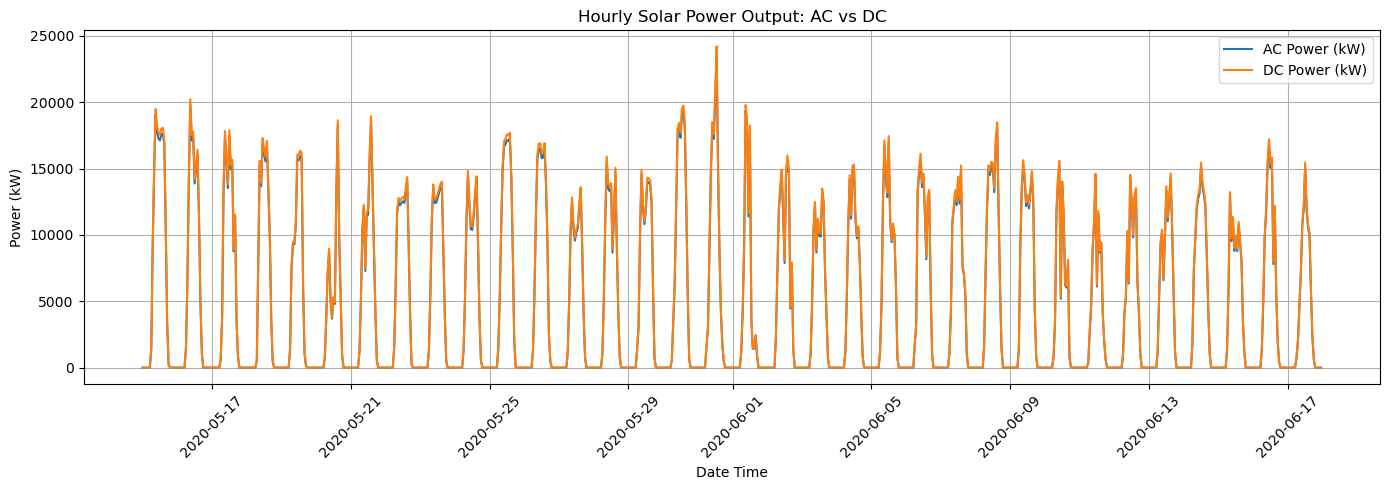

In [37]:
plot_data = (solar_data.set_index("DATE_TIME")[["ACTUAL_AC_POWER(kW)",
             "ACTUAL_DC_POWER(kW)"]].resample("1h").mean())

plt.figure(figsize=(14,5))

plt.plot(plot_data.index,plot_data["ACTUAL_AC_POWER(kW)"],label="AC Power (kW)")

plt.plot(plot_data.index,plot_data["ACTUAL_DC_POWER(kW)"],label="DC Power (kW)")

plt.title("Hourly Solar Power Output: AC vs DC")
plt.xlabel("Date Time")
plt.ylabel("Power (kW)")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

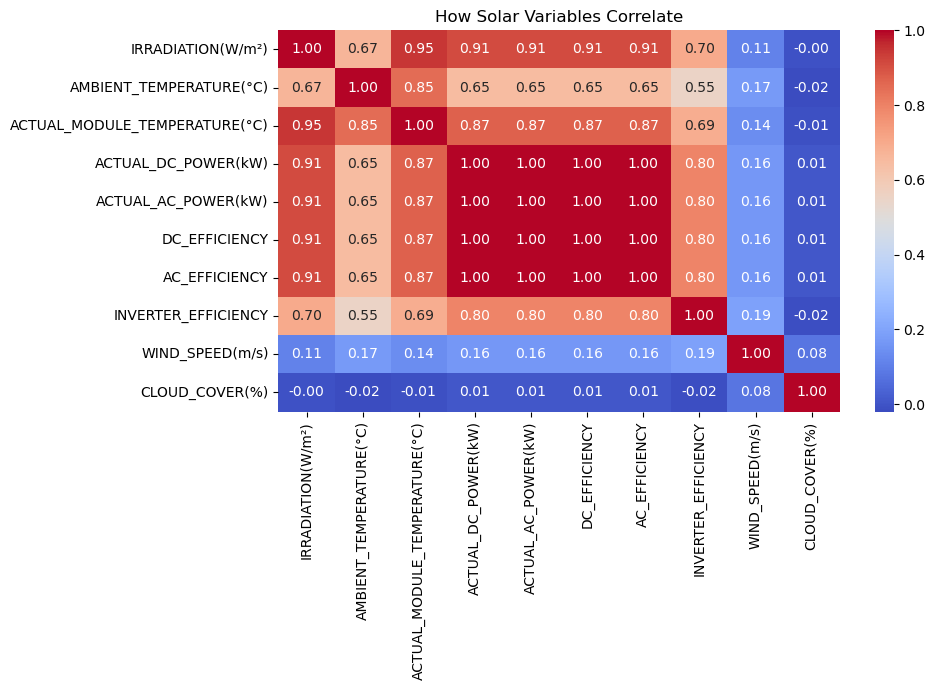

In [38]:
plt.figure(figsize=(10, 7))
numeric_cols = [
    'IRRADIATION(W/m²)', 'AMBIENT_TEMPERATURE(°C)', 'ACTUAL_MODULE_TEMPERATURE(°C)', 
    'ACTUAL_DC_POWER(kW)', 'ACTUAL_AC_POWER(kW)', 'DC_EFFICIENCY', 'AC_EFFICIENCY', 'INVERTER_EFFICIENCY', 
    'WIND_SPEED(m/s)', 'CLOUD_COVER(%)'
]
corr_matrix = solar_data[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('How Solar Variables Correlate')
plt.tight_layout()
plt.show()

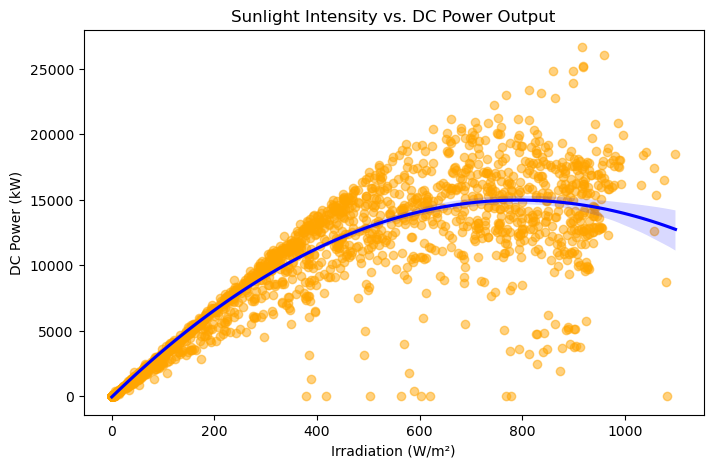

In [39]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=solar_data, 
    x='IRRADIATION(W/m²)', 
    y='ACTUAL_DC_POWER(kW)',
    order=3,  # Fit a quadratic regression line 
    scatter_kws={'alpha': 0.5, 'color': 'orange'}, 
    line_kws={'color': 'blue'}
)
plt.title('Sunlight Intensity vs. DC Power Output')
plt.xlabel('Irradiation (W/m²)')
plt.ylabel('DC Power (kW)')
plt.show()

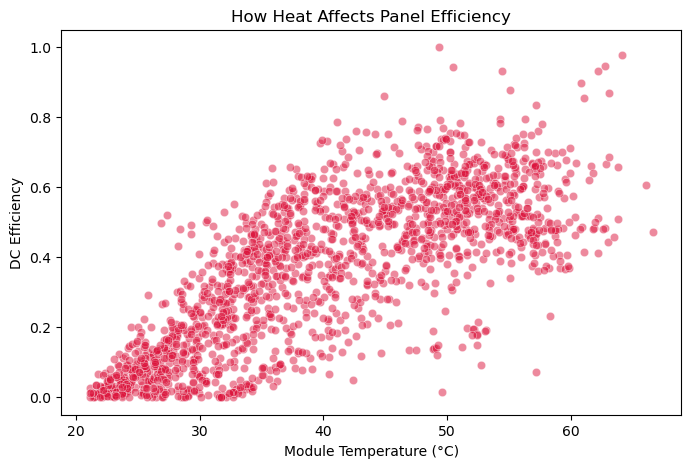

In [40]:
daytime_data = solar_data[solar_data['ACTUAL_DC_POWER(kW)'] > 0]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=daytime_data, 
    x='ACTUAL_MODULE_TEMPERATURE(°C)', 
    y='DC_EFFICIENCY', 
    alpha=0.5, 
    color='crimson'
)
plt.title('How Heat Affects Panel Efficiency')
plt.xlabel('Module Temperature (°C)')
plt.ylabel('DC Efficiency')
plt.show()

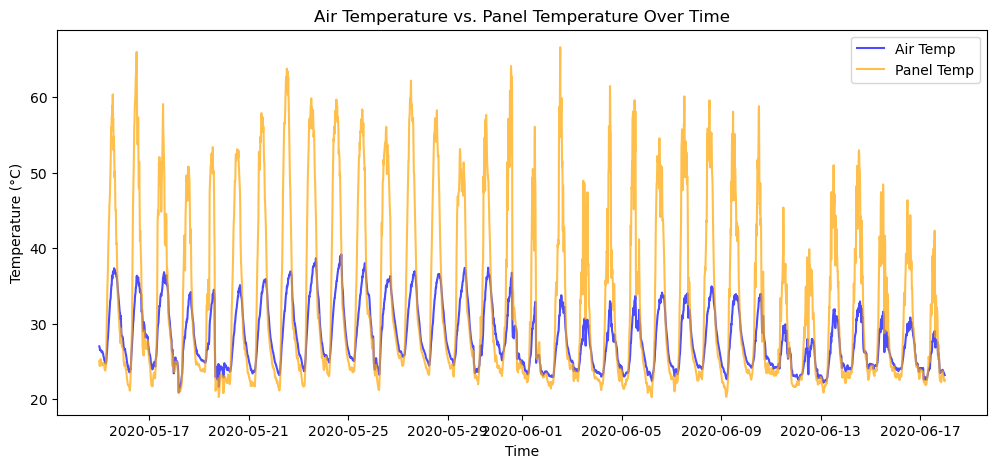

In [41]:
# 4. Air Temp vs. Panel Temp
plt.figure(figsize=(12, 5))
plt.plot(solar_data['DATE_TIME'], solar_data['AMBIENT_TEMPERATURE(°C)'], label='Air Temp', color='blue', alpha=0.7)
plt.plot(solar_data['DATE_TIME'], solar_data['ACTUAL_MODULE_TEMPERATURE(°C)'], label='Panel Temp', color='orange', alpha=0.7)
plt.title('Air Temperature vs. Panel Temperature Over Time')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

In [42]:
active_inverter = solar_data[(solar_data['ACTUAL_DC_POWER(kW)'] > 0) & (solar_data['INVERTER_EFFICIENCY'] > 0)]

fig_inv = px.scatter(
    active_inverter, 
    x='ACTUAL_AC_POWER(kW)', 
    y='INVERTER_EFFICIENCY', 
    title='Inverter Efficiency Curve',
    labels={'ACTUAL_AC_POWER(kW)': 'Output AC Power (kW)', 'INVERTER_EFFICIENCY': 'Inverter Efficiency'},
    template='plotly_white'
)
fig_inv.show()

In [43]:
fig_yield = px.line(
    solar_data, 
    x='DATE_TIME', 
    y='TOTAL_YIELD(kWh)', 
    title='Daily Energy Production (Total Yield)',
    labels={'TOTAL_YIELD(kWh)': 'Total Yield (kWh)', 'DATE_TIME': 'Date'},
    template='plotly_white'
)
fig_yield.show(config={"scrollZoom": True})

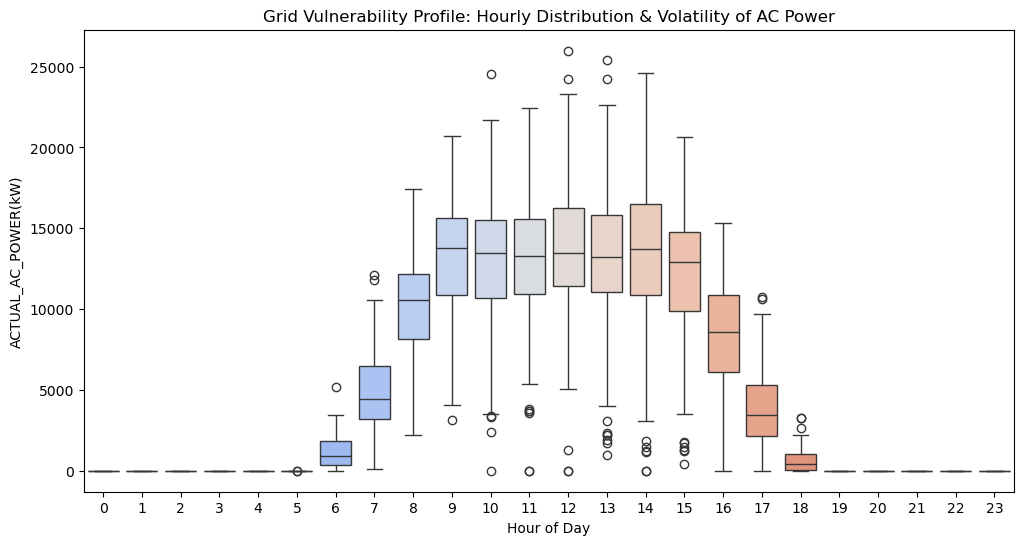

In [44]:
# Power distibution per hour
solar_data['hour'] = pd.to_datetime(solar_data['DATE_TIME']).dt.hour

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=solar_data, 
    x='hour', 
    y='ACTUAL_AC_POWER(kW)', 
    hue='hour', 
    palette='coolwarm', 
    legend=False
)

plt.title('Grid Vulnerability Profile: Hourly Distribution & Volatility of AC Power')
plt.xlabel('Hour of Day')
plt.ylabel('ACTUAL_AC_POWER(kW)')
plt.show()

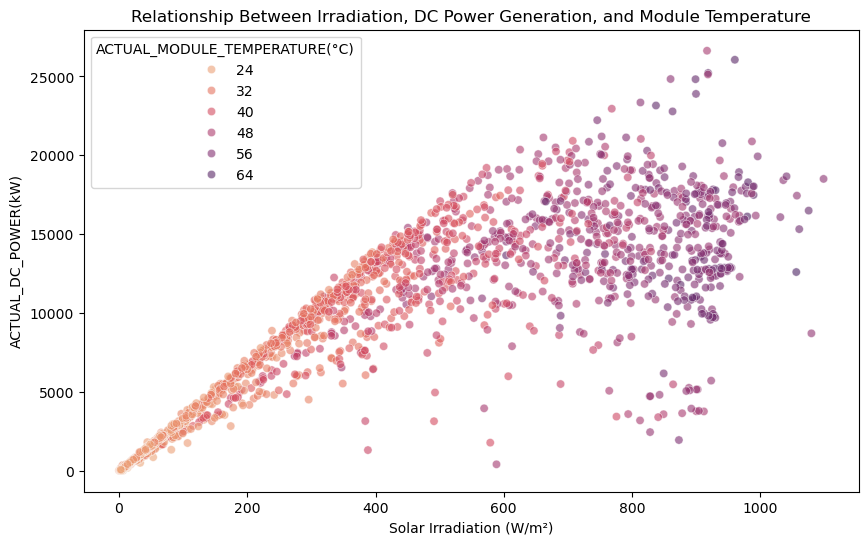

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=daytime_data,
    x='IRRADIATION(W/m²)', 
    y='ACTUAL_DC_POWER(kW)', 
    hue='ACTUAL_MODULE_TEMPERATURE(°C)', 
    palette='flare',
    alpha=0.6
)
plt.title('Relationship Between Irradiation, DC Power Generation, and Module Temperature')
plt.xlabel('Solar Irradiation (W/m²)')
plt.ylabel('ACTUAL_DC_POWER(kW)')
plt.show()

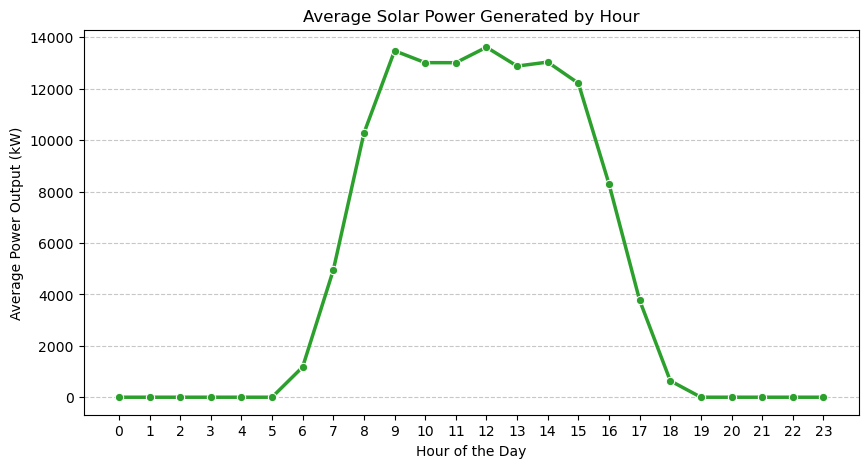

In [46]:
hourly_avg = solar_data.groupby('hour')['ACTUAL_AC_POWER(kW)'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_avg, x='hour', y='ACTUAL_AC_POWER(kW)', marker='o', color='#2ca02c', linewidth=2.5)

plt.title('Average Solar Power Generated by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Power Output (kW)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(0, 24))
plt.show()